# Investigación del comportamiento usuarios

# Paso 1. Abrir el archivo de datos y leer la información general

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
logs = pd.read_csv('/datasets/logs_exp_us.csv', sep='\t')
logs.head()

,EventName,DeviceIDHash,EventTimestamp,ExpId
0,MainScreenAppear,4575588528974610257,1564029816,246
1,MainScreenAppear,7416695313311560658,1564053102,246
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248
3,CartScreenAppear,3518123091307005509,1564054127,248
4,PaymentScreenSuccessful,6217807653094995999,1564055322,248


In [ ]:
logs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   EventName       244126 non-null  object
 1   DeviceIDHash    244126 non-null  int64 
 2   EventTimestamp  244126 non-null  int64 
 3   ExpId           244126 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 7.5+ MB


La tabla de informacion nos muestra que no hay datos nulos, pero algunos de los tipos que pueden ser categoricos, no lo son.

# Paso 2. Preparar los datos para el análisis

In [ ]:
logs['EventName'] = logs['EventName'].astype('category')
logs['ExpId'] = logs['ExpId'].astype('category')
logs['EventDateTime'] = pd.to_datetime(logs['EventTimestamp'], unit='s')
logs['EventDate'] = logs['EventDateTime'].dt.date

In [ ]:
logs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   EventName       244126 non-null  category      
 1   DeviceIDHash    244126 non-null  int64         
 2   EventTimestamp  244126 non-null  int64         
 3   ExpId           244126 non-null  category      
 4   EventDateTime   244126 non-null  datetime64[ns]
 5   EventDate       244126 non-null  object        
dtypes: category(2), datetime64[ns](1), int64(2), object(1)
memory usage: 7.9+ MB


In [ ]:
logs.head()

,EventName,DeviceIDHash,EventTimestamp,ExpId,EventDateTime,EventDate
0,MainScreenAppear,4575588528974610257,1564029816,246,2019-07-25 04:43:36,2019-07-25
1,MainScreenAppear,7416695313311560658,1564053102,246,2019-07-25 11:11:42,2019-07-25
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248,2019-07-25 11:28:47,2019-07-25
3,CartScreenAppear,3518123091307005509,1564054127,248,2019-07-25 11:28:47,2019-07-25
4,PaymentScreenSuccessful,6217807653094995999,1564055322,248,2019-07-25 11:48:42,2019-07-25


# Paso 3. Estudiar y comprobar los datos

## ¿Cuántos eventos hay en los registros?

In [ ]:
total_events = logs.shape[0]
print('El numero de eventos es', total_events)

El numero de eventos es 244126


## ¿Cuántos usuarios hay en los registros?

In [ ]:
total_users = logs['DeviceIDHash'].nunique()
print('El numero de usuarios es', total_users)

El numero de usuarios es 7551


## ¿Cuál es el promedio de eventos por usuario?

In [ ]:
events_per_user = (
    logs
    .groupby('DeviceIDHash')
    .size()
)

avg_events_per_user = events_per_user.mean()
avg_events_per_user

print('El promedio de eventos por usuario es', avg_events_per_user)

El promedio de eventos por usuario es 32.33028737915508


## ¿Qué periodo de tiempo cubren los datos? Encuentra la fecha máxima y mínima.

In [ ]:
logs['EventDateTime'].min(), logs['EventDateTime'].max()

(Timestamp('2019-07-25 04:43:36'), Timestamp('2019-08-07 21:15:17'))

## ¿Puedes tener seguridad de que tienes datos igualmente completos para todo el periodo? Los eventos más antiguos podrían terminar en los registros de algunos usuarios por razones técnicas y esto podría sesgar el panorama general. Encuentra el momento en el que los datos comienzan a estar completos e ignora la sección anterior. ¿Qué periodo representan realmente los datos?

In [ ]:
events_by_date = (
    logs
    .groupby('EventDate')
    .size()
    .reset_index(name='events')
)

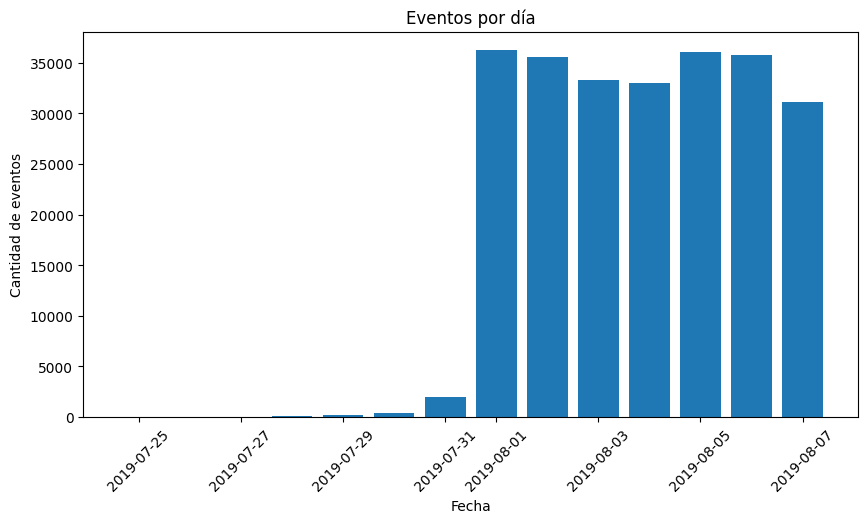

In [ ]:
plt.figure(figsize=(10,5))
plt.bar(events_by_date['EventDate'], events_by_date['events'])
plt.xticks(rotation=45)
plt.title('Eventos por día')
plt.xlabel('Fecha')
plt.ylabel('Cantidad de eventos')
plt.show()

El análisis del número de eventos por día muestra que antes del 1 de agosto de 2019 los datos son escasos e irregulares, lo que sugiere un registro incompleto de eventos. A partir de esa fecha, el volumen diario se estabiliza y se observa una actividad consistente. Por este motivo, se excluyen los datos anteriores para evitar sesgos en el análisis posterior.

In [ ]:
cutoff_date = pd.to_datetime('2019-08-01').date()

logs_clean = logs[logs['EventDate'] >= cutoff_date].copy()

In [ ]:
print('Eventos originales:', logs.shape[0])
print('Eventos después de limpieza:', logs_clean.shape[0])

Eventos originales: 244126
Eventos después de limpieza: 241298


In [ ]:
print('Usuarios originales:', logs['DeviceIDHash'].nunique())
print('Usuarios después de limpieza:', logs_clean['DeviceIDHash'].nunique())

Usuarios originales: 7551
Usuarios después de limpieza: 7534


<AxesSubplot:xlabel='EventDate'>

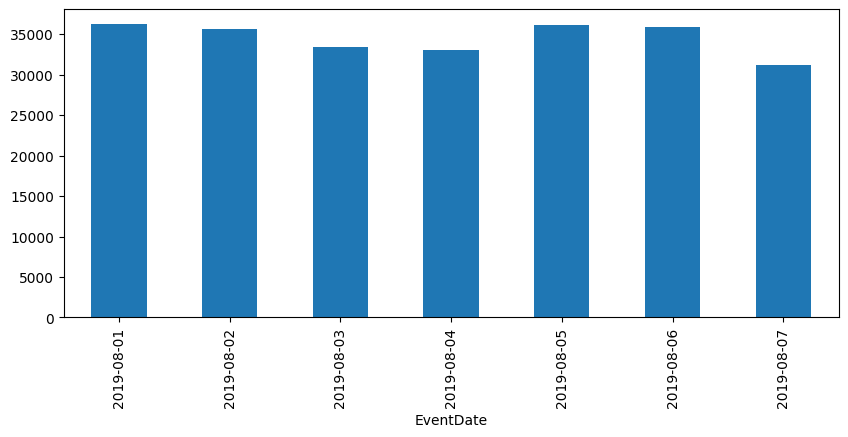

In [ ]:
logs_clean.groupby('EventDate').size().plot(kind='bar', figsize=(10,4))

## ¿Qué periodo representan realmente los datos?

In [ ]:
logs_clean['EventDateTime'].min(), logs_clean['EventDateTime'].max()

(Timestamp('2019-08-01 00:07:28'), Timestamp('2019-08-07 21:15:17'))

Tras eliminar los registros iniciales con baja densidad de eventos, el periodo efectivo de análisis comprende desde el 1 de agosto de 2019 hasta el 7 de agosto de 2019, intervalo en el cual los datos presentan un volumen estable y consistente.

## ¿Perdiste muchos eventos y usuarios al excluir los datos más antiguos?

In [ ]:
diff = logs['DeviceIDHash'].nunique() - logs_clean['DeviceIDHash'].nunique()

In [ ]:
cleaned_percent = diff / logs['DeviceIDHash'].nunique()
diff, cleaned_percent

(17, 0.0022513574361011784)

Se eliminaron 17 usuarios, lo que representa aproximadamente el 0.23% del total. Esta pérdida es marginal y no afecta la representatividad de la muestra ni las conclusiones del análisis.

## Asegúrate de tener usuarios de los tres grupos experimentales.

In [ ]:
logs_clean['ExpId'].value_counts()

248    84726
246    79425
247    77147
Name: ExpId, dtype: int64

# Paso 4. Estudiar el embudo de eventos

## Observa qué eventos hay en los registros y su frecuencia de suceso. Ordénalos por frecuencia.

In [ ]:
event_counts = (
    logs_clean
    .groupby('EventName')
    .size()
    .sort_values(ascending=False)
)

event_counts

EventName
MainScreenAppear           117431
OffersScreenAppear          46350
CartScreenAppear            42365
PaymentScreenSuccessful     34113
Tutorial                     1039
dtype: int64

## Encuentra la cantidad de usuarios que realizaron cada una de estas acciones. Ordena los eventos por el número de usuarios. Calcula la proporción de usuarios que realizaron la acción al menos una vez.

In [ ]:
# Total de usuarios únicos
total_users = logs_clean['DeviceIDHash'].nunique()

# Usuarios únicos por evento
users_per_event = (
    logs_clean
    .groupby('EventName')['DeviceIDHash']
    .nunique()
    .sort_values(ascending=False)
)

# Proporción de usuarios
event_user_share = (users_per_event / total_users).round(4) * 100

# Resultado final
event_funnel = pd.DataFrame({
    'users': users_per_event,
    'share': event_user_share
})

event_funnel

,users,share
EventName,,
MainScreenAppear,7419,98.47
OffersScreenAppear,4593,60.96
CartScreenAppear,3734,49.56
PaymentScreenSuccessful,3539,46.97
Tutorial,840,11.15


Los porcentajes representan la proporción de usuarios únicos que realizaron cada evento al menos una vez.
No constituyen aún un embudo, ya que el denominador es el total de usuarios y no los usuarios que iniciaron una secuencia específica.
Por ello, el evento inicial no alcanza el 100%.

## ¿En qué orden crees que ocurrieron las acciones? ¿Todas son parte de una sola secuencia? No es necesario tenerlas en cuenta al calcular el embudo.

Las acciones parecen seguir un orden lógico que va desde la pantalla principal hasta el pago exitoso: MainScreenAppear → OffersScreenAppear → CartScreenAppear → PaymentScreenSuccessful.
Sin embargo, no todos los eventos forman parte de una única secuencia. En particular, el evento Tutorial es opcional y no está directamente relacionado con el proceso de compra.
Además, el comportamiento real de los usuarios puede incluir saltos, repeticiones o accesos directos, por lo que el embudo debe analizarse considerando solo los eventos clave del flujo de compra.

## Utiliza el embudo de eventos para encontrar la proporción de usuarios que pasan de una etapa a la siguiente. Por ejemplo, para la secuencia de eventos A → B → C, calcula la proporción de usuarios en la etapa B a la cantidad de usuarios en la etapa A y la proporción de usuarios en la etapa C a la cantidad en la etapa B.

In [ ]:
funnel_events = [
    'MainScreenAppear',
    'OffersScreenAppear',
    'CartScreenAppear',
    'PaymentScreenSuccessful'
]

funnel_users = (
    logs_clean[logs_clean['EventName'].isin(funnel_events)]
    .groupby('EventName')['DeviceIDHash']
    .nunique()
    .reindex(funnel_events)
)

funnel_users

EventName
MainScreenAppear           7419
OffersScreenAppear         4593
CartScreenAppear           3734
PaymentScreenSuccessful    3539
Name: DeviceIDHash, dtype: int64

In [ ]:
funnel_conversion = (funnel_users / funnel_users.shift(1)).round(4)*100
funnel_conversion

EventName
MainScreenAppear             NaN
OffersScreenAppear         61.91
CartScreenAppear           81.30
PaymentScreenSuccessful    94.78
Name: DeviceIDHash, dtype: float64

In [ ]:
funnel_df = pd.DataFrame({
    'users': funnel_users,
    'conversion_from_previous': funnel_conversion
})

funnel_df

,users,conversion_from_previous
EventName,,
MainScreenAppear,7419,NaN
OffersScreenAppear,4593,61.91
CartScreenAppear,3734,81.30
PaymentScreenSuccessful,3539,94.78


## ¿En qué etapa pierdes más usuarios?

La mayor pérdida de usuarios ocurre en la etapa inicial del embudo, entre la aparición de la pantalla principal y la pantalla de ofertas.
Sin embargo, una vez que los usuarios avanzan hacia etapas posteriores, la probabilidad de completar la compra es muy alta.

## ¿Qué porcentaje de usuarios hace todo el viaje desde su primer evento hasta el pago?

In [ ]:
# Usuarios que inician el embudo
users_start = funnel_df.loc['MainScreenAppear', 'users']

# Usuarios que completan el pago
users_paid = funnel_df.loc['PaymentScreenSuccessful', 'users']

# Porcentaje de usuarios que completan todo el embudo
full_funnel_conversion = users_paid / users_start * 100

print(
    f"El {full_funnel_conversion:.2f}% de los usuarios completa todo el recorrido "
    "desde el primer evento hasta el pago."
)


El 47.70% de los usuarios completa todo el recorrido desde el primer evento hasta el pago.


# Paso 5. Estudiar los resultados del experimento

## ¿Cuántos usuarios hay en cada grupo?

In [ ]:
users_per_group = (
    logs_clean
    .groupby('ExpId')['DeviceIDHash']
    .nunique()
    .sort_index()
)


In [ ]:
for group, users in users_per_group.items():
    print(f"Grupo {group}: {users} usuarios únicos")

Grupo 246: 2484 usuarios únicos
Grupo 247: 2513 usuarios únicos
Grupo 248: 2537 usuarios únicos


## Tenemos dos grupos de control en el test A/A, donde comprobamos nuestros mecanismos y cálculos. Observa si hay una diferencia estadísticamente significativa entre las muestras 246 y 247.

## Selecciona el evento más popular. En cada uno de los grupos de control, encuentra la cantidad de usuarios que realizaron esta acción. Encuentra su proporción. Comprueba si la diferencia entre los grupos es estadísticamente significativa. Repite el procedimiento para todos los demás eventos (ahorrarás tiempo si creas una función especial para esta prueba). ¿Puedes confirmar que los grupos se dividieron correctamente?

In [ ]:
from scipy import stats
import numpy as np

def z_test_proportions(success_a, size_a, success_b, size_b):
    p1 = success_a / size_a
    p2 = success_b / size_b

    p_pool = (success_a + success_b) / (size_a + size_b)
    se = np.sqrt(p_pool * (1 - p_pool) * (1/size_a + 1/size_b))

    z = (p1 - p2) / se
    p_value = 2 * (1 - stats.norm.cdf(abs(z)))

    return p_value


In [ ]:
events = (
    logs_clean
    .groupby('EventName')['DeviceIDHash']
    .nunique()
    .sort_values(ascending=False)
    .index
)


In [ ]:

results_aa = []

for event in events:
    users_246 = (
        logs_clean[
            (logs_clean['ExpId'] == 246) &
            (logs_clean['EventName'] == event)
        ]['DeviceIDHash']
        .nunique()
    )

    users_247 = (
        logs_clean[
            (logs_clean['ExpId'] == 247) &
            (logs_clean['EventName'] == event)
        ]['DeviceIDHash']
        .nunique()
    )

    p_value = z_test_proportions(
    users_246, users_per_group.loc[246],
    users_247, users_per_group.loc[247]
)

    results_aa.append({
        'EventName': event,
        'Users_246': users_246,
        'Users_247': users_247,
        'p_value': p_value
    })

aa_results = pd.DataFrame(results_aa)
aa_results


,EventName,Users_246,Users_247,p_value
0,MainScreenAppear,2450,2476,0.757060
1,OffersScreenAppear,1542,1520,0.248095
2,CartScreenAppear,1266,1238,0.228834
3,PaymentScreenSuccessful,1200,1158,0.114567
4,Tutorial,278,283,0.937700


In [ ]:
alpha = 0.05
n_tests = aa_results.shape[0]
alpha_adj = alpha / n_tests

aa_results['significant'] = aa_results['p_value'] < alpha_adj
aa_results


,EventName,Users_246,Users_247,p_value,significant
0,MainScreenAppear,2450,2476,0.757060,False
1,OffersScreenAppear,1542,1520,0.248095,False
2,CartScreenAppear,1266,1238,0.228834,False
3,PaymentScreenSuccessful,1200,1158,0.114567,False
4,Tutorial,278,283,0.937700,False


In [ ]:
aa_results['significant'].value_counts()


False    5
Name: significant, dtype: int64

No se encontraron diferencias estadísticamente significativas entre los grupos de control 246 y 247 para ninguno de los eventos analizados.
Esto indica que la división de usuarios se realizó correctamente y que el sistema de recopilación de datos y el enfoque estadístico son confiables.

## Haz lo mismo para el grupo con fuentes alteradas. Compara los resultados con los de cada uno de los grupos de control para cada evento de forma aislada. Compara los resultados con los resultados combinados de los grupos de control. ¿Qué conclusiones puedes sacar del experimento?

In [ ]:
users_per_event_group = (
    logs_clean
    .groupby(['ExpId', 'EventName'])['DeviceIDHash']
    .nunique()
    .reset_index(name='users')
)

users_per_event_group.head()


,ExpId,EventName,users
0,246,CartScreenAppear,1266
1,246,MainScreenAppear,2450
2,246,OffersScreenAppear,1542
3,246,PaymentScreenSuccessful,1200
4,246,Tutorial,278


In [ ]:
import math
from scipy import stats

def z_test_proportions(success1, size1, success2, size2):
    p1 = success1 / size1
    p2 = success2 / size2
    p_combined = (success1 + success2) / (size1 + size2)

    z = (p1 - p2) / math.sqrt(
        p_combined * (1 - p_combined) * (1/size1 + 1/size2)
    )

    p_value = 2 * (1 - stats.norm.cdf(abs(z)))
    return p_value


In [ ]:
results = []

alpha = 0.1
n_tests = len(events) * 2
alpha_corrected = alpha / n_tests

for event in events:
    users_248 = users_per_event_group.query(
        "ExpId == 248 and EventName == @event"
    )['users'].values[0]

    for control in [246, 247]:
        users_control = users_per_event_group.query(
            "ExpId == @control and EventName == @event"
        )['users'].values[0]

        p_value = z_test_proportions(
            users_248, users_per_group.loc[248],
            users_control, users_per_group.loc[control]
        )

        results.append({
            'event': event,
            'comparison': f'248 vs {control}',
            'p_value': p_value,
            'significant': p_value < alpha_corrected
        })


In [ ]:
for event in events:
    users_248 = users_per_event_group.query(
        "ExpId == 248 and EventName == @event"
    )['users'].values[0]

    users_control_combined = users_per_event_group.query(
        "ExpId in [246,247] and EventName == @event"
    )['users'].sum()

    size_control_combined = (
        users_per_group.loc[246] + users_per_group.loc[247]
    )

    p_value = z_test_proportions(
        users_248, users_per_group.loc[248],
        users_control_combined, size_control_combined
    )

    results.append({
        'event': event,
        'comparison': '248 vs control_combined',
        'p_value': p_value,
        'significant': p_value < alpha_corrected
    })


In [ ]:
import pandas as pd

results_df = pd.DataFrame(results)
results_df


,event,comparison,p_value,significant
0,MainScreenAppear,248 vs 246,0.294972,False
1,MainScreenAppear,248 vs 247,0.458705,False
2,OffersScreenAppear,248 vs 246,0.208362,False
3,OffersScreenAppear,248 vs 247,0.919782,False
4,CartScreenAppear,248 vs 246,0.078429,False
5,CartScreenAppear,248 vs 247,0.578620,False
6,PaymentScreenSuccessful,248 vs 246,0.212255,False
7,PaymentScreenSuccessful,248 vs 247,0.737342,False
8,Tutorial,248 vs 246,0.826429,False
9,Tutorial,248 vs 247,0.765324,False


## ¿Qué nivel de significancia has establecido para probar las hipótesis estadísticas mencionadas anteriormente? Calcula cuántas pruebas de hipótesis estadísticas has realizado. Con un nivel de significancia estadística de 0.1, uno de cada 10 resultados podría ser falso. ¿Cuál debería ser el nivel de significancia? Si deseas cambiarlo, vuelve a ejecutar los pasos anteriores y comprueba tus conclusiones.

Para el test A/A entre los grupos de control (246 y 247) se utilizó un nivel de significancia de 0.05, ya que el objetivo era validar la correcta división de los usuarios y el funcionamiento del sistema experimental. No se encontraron diferencias estadísticamente significativas, lo que confirma la validez del experimento.

Para el análisis A/B, se estableció un nivel de significancia inicial de 0.1. Dado que se realizaron múltiples pruebas de hipótesis, se aplicó una corrección de Bonferroni para ajustar el nivel de significancia. Tras aplicar dicha corrección, no se identificaron diferencias estadísticamente significativas entre el grupo experimental y los grupos de control, ni de forma individual ni combinada. Por lo que se concluye que el cambio de fuentes no tuvo un impacto significativo en el comportamiento de los usuarios.